In [ ]:
# Install required libraries
!pip install -q torch                                  # Pytorch
!pip install -q transformers datasets                  # Comes from HuggingFace
!pip install -U bitsandbytes                           # For quantization from HuggingFace
!pip install -q peft                                   # Parameter-efficient Fine-tuning from HuggingFace
!pip install -q trl                                    # For supervised fine-tuning for LLMs from HuggingFace
!pip install -q accelerate                             # For distributed training from HuggingFace
!pip install evaluate
!pip install bitsandbytes
!pip install evaluate unbabel-comet

# 1. Load OPUS_BOOKS dataset [Dataset A] and split it according to the designed ratio.

In [ ]:
# Load the dataset from HuggingFace
!pip install datasets
from datasets import load_dataset

# Download and load the dataset
dataset = load_dataset("Helsinki-NLP/opus_books", "de-fr")

In [3]:
#clean dataset, change datatype to Dataset from list

import re
from datasets import Dataset

def clean_text(text):
    """Cleans and normalizes text."""
    if not text:  # Handle empty values
        return ""

    text = text.strip()  # Remove leading/trailing spaces
    text = re.sub(r'[_"\'«»]', "", text)  # Removes _, ", ', «, »
    text = re.sub(r'--', "", text)  # Removes --
    text = re.sub(r"\s+", " ", text)  # Normalize spaces (convert multiple spaces to one)
    text = re.sub(r"http\S+|www\S+", "", text) #remove links or urls

    return text

def preprocess_dataset(sampled_dataset):
    """Applies text preprocessing: removes empty entries, cleans text, and normalizes format."""
    cleaned_data = []

    for entry in sampled_dataset:
        de_text = clean_text(entry['translation'].get('de', ''))
        fr_text = clean_text(entry['translation'].get('fr', ''))

        # Remove entries where either German or French text is missing
        if de_text and fr_text:
            cleaned_data.append({'id': entry['id'], 'translation': {'de': de_text, 'fr': fr_text}})

    return cleaned_data

# Preprocess the dataset
dataset = preprocess_dataset(dataset['train'])
dataset = Dataset.from_list(dataset)
dataset

Dataset({
    features: ['id', 'translation'],
    num_rows: 34916
})

In [ ]:
# Let's view an example from the training dataset
dataset["translation"][:5]

[{'de': 'Source:  - Contumax GmbH & Co. KG',
  'fr': 'Source: Project GutenbergTranslation: Noëmie Lesbazeilles-Souvestre'},
 {'de': 'Jane Eyre', 'fr': 'Jane Eyre'},
 {'de': 'Charlotte Bronte', 'fr': 'Charlotte Brontë'},
 {'de': 'Erstes Kapitel', 'fr': 'CHAPITRE PREMIER'},
 {'de': 'Es war ganz unmöglich, an diesem Tage einen Spaziergang zu machen.',
  'fr': 'Il était impossible de se promener ce jour-là.'}]

In [4]:
# Define a function to build a prompt from a data example
def format_instruction(german_text, french_text):
    return f"""###Instruction:
Translate the following German text into French.

###German:
{german_text.strip()}

###French:
{french_text.strip()}
"""
# Use strip() to remove any extra spaces

# Define a function that converts a dataset row into the corresponding prompt format
def convert_to_instruction_format(data_point):
    return {
        "full_prompt": format_instruction(data_point["translation"]["de"], data_point["translation"]["fr"]), "german_text": data_point["translation"]["de"],"label_french": data_point["translation"]["fr"]
        }

# Apply the function to each row in the dataset
def process_dataset(data):
    return data.map(
        convert_to_instruction_format
        ).remove_columns(['id', 'translation']) #removing unnecessary columns

In [5]:
processed_dataset = process_dataset(
    dataset.shuffle(seed=42).select([i for i in range(1000)]) # take random 1000 training example
    )
processed_dataset

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['full_prompt', 'german_text', 'label_french'],
    num_rows: 1000
})

In [6]:
# split processed_dataset into train and test of 80:20 ratio

from datasets import DatasetDict

# Assuming 'processed_dataset' is your processed dataset as a Dataset object
train_test_dataset = DatasetDict({
    'train': processed_dataset.select(range(int(0.8 * len(processed_dataset)))),
    'test': processed_dataset.select(range(int(0.8 * len(processed_dataset)), len(processed_dataset)))
})

train_split = train_test_dataset['train']
test_split = train_test_dataset['test']
# Now you have two datasets: train_test_dataset['train'] and train_test_dataset['test']
print(f"Train dataset size: {len(train_split)}")
print(f"Test dataset size: {len(test_split)}")


Train dataset size: 800
Test dataset size: 200


In [7]:
train_split

Dataset({
    features: ['full_prompt', 'german_text', 'label_french'],
    num_rows: 800
})

In [8]:
#save as json

import json

# Convert to a list of dictionaries
dataset_A_train = train_split.to_list()
dataset_A_test = test_split.to_list()

# Save to a JSON file
with open("dataset_A_train.json", "w", encoding="utf-8") as f:
    json.dump(dataset_A_train, f, indent=4, ensure_ascii=False)

with open("dataset_A_test.json", "w", encoding="utf-8") as f:
    json.dump(dataset_A_test, f, indent=4, ensure_ascii=False)

print("Dataset saved as json")



Dataset saved as json


# 2. Load your chosen pre-trained model [Model A].

In [46]:
# Get the tokenizer object from HuggingFace
from transformers import AutoTokenizer

# Download and initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Set the padding token to be the same as the end-of-sequence token.
# Padding ensures all sequences in a batch are of equal length.
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be applied to the right side of the sequences.
# This is the standard behavior for Mistral and many other causal language models.
tokenizer.padding_side = "right"

In [10]:
# Load BitsAndBytes object from HuggingFace Transformers
from transformers import BitsAndBytesConfig
import torch

# Set up the quantization configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # Use 4-bit quantization (Q = 4 bits)
    bnb_4bit_use_double_quant=True,        # Double quantization: quantize the quantization constants to save an additional 0.4 bits per parameter
    bnb_4bit_quant_type="nf4",             # Use 4-bit NormalFloat Quantization (optimal for normal weights; enforces w ∈ [-1,1])
    bnb_4bit_compute_dtype=torch.bfloat16  # Dequantize to 16-bits before computation (as described in the paper)
)

# Pass the quantization configuration when loading the model
from transformers import AutoModelForCausalLM

# Load the quantized model
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct",
                                             quantization_config=quant_config)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`low_cpu_mem_usage` was None, now default to True since model is quantized.


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# 3. Evaluate [Model A] on the test dataset [Dataset A: Test] using the chosen metric.

In [ ]:
# Test Qwen on Dataset A test
def translate_text(german_text):
    prompt = f"""
    Translate the following German text into French.

    ### German: {german_text}

    ### French:
    """

    inputs = tokenizer(prompt, return_tensors='pt')
    inputs = inputs.to("cuda")
    # Generate response
    output_tokens = model.generate(inputs["input_ids"],
                                  max_new_tokens=100,
                                  pad_token_id=model.config.eos_token_id)[0]
    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    res = output.replace(prompt, "")
    return res

# Pre-training evaluation with COMET and BLEU
import evaluate
from datasets import Dataset
from comet import download_model, load_from_checkpoint

# Load COMET model
comet_model_path = download_model("Unbabel/wmt22-comet-da")  # Latest COMET model
comet_model = load_from_checkpoint(comet_model_path)

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

def evaluate_model(test_dataset):
    predictions, references = [], []

    for row in test_dataset:
        german_input = row["german_text"]  # German sentence
        true_french = row["label_french"]  # Ground truth translation

        # Generate model translation
        predicted_french = translate_text(german_input)  # Ensure it returns a full string sentence

        # Store full sentence predictions & references (not tokenized yet)
        predictions.append(predicted_french)
        references.append([true_french])  # list of references

    # Compute COMET score
    comet_data = [{"src": example["german_text"], "mt": pred, "ref": example["label_french"]}
                 for pred, example in zip(predictions, test_dataset)]
    comet_scores = comet_model.predict(comet_data, batch_size=8, gpus=1)  # Adjust batch_size and gpus as needed
    comet_score = comet_scores.system_score

    # Compute BLEU score
    bleu_score = bleu_metric.compute(predictions=predictions, references=references)

    return {
        "comet": comet_score,
        "bleu": bleu_score["bleu"],
    }

# Evaluate the model on test data
scores = evaluate_model(test_split)
print(f"COMET Score: {scores['comet']:.4f}")
print(f"BLEU Score: {scores['bleu']:.4f}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 25/25 [00:08<

COMET Score: 0.3980
BLEU Score: 0.0151


In [ ]:
#save scores in json

import json

result = {'model': 'Model A', 'bleu score': round(scores['bleu'],4), 'comet score': round(scores['comet'],4)}

with open("metrics.json", "w") as f:
    json.dump(result, f, indent=4)


# 4. Fine-tune [Model A] on the training dataset [Dataset A: Train] to create [Model B].

In [ ]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps

In [11]:
# Import necessary PEFT objects for preparing the model for LoRA training
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Prepare the model for LoRA, which includes float conversions to help stabilize training
model = prepare_model_for_kbit_training(model)

# Set up LoRA configuration
lora_config = LoraConfig(
    r=16,                                                       # The rank (dimensions) of the LoRA matrices A and B
    lora_alpha=64,                                              # Scales the product of matrices AB [W_new = W_old + (A * B) * α]
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],    # Apply LoRA to the attention matrices
    lora_dropout=0.1,                                           # Dropout rate to reduce overfitting
    bias="none",                                                # Do not train the bias parameter
    task_type="CAUSAL_LM"                                       # Task type for autoregressive text generation
)

# Get the model with unfrozen LoRA layers applied
model = get_peft_model(model, lora_config)


In [12]:
from trl import SFTConfig

# Set up the training hyperparameters
training_arguments = SFTConfig(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)
    dataset_text_field="full_prompt",           # Specify the text field in the dataset for training
    max_seq_length=1024,                 # Set the maximum sequence length for the training data

    # Batch-related parameters
    per_device_train_batch_size=8,       # Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_32bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=1e-4,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=3,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./epoch-finetuned",      # Directory to save the fine-tuned model

    # Validation-related parameters
    eval_strategy="steps",               # Evaluation strategy, performed at specified steps
    eval_steps=50,                      # Evaluate after 100 training steps

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
)

# Enable gradient checkpointing to save memory and recompute during backpropagation
model.gradient_checkpointing_enable()

# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = False

In [13]:
# Import the SFTTrainer from HuggingFace TRL library
from trl import SFTTrainer

#loading test_split from dataset A for eval parameter

# Initialize the trainer
trainer = SFTTrainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training and validation datasets
    train_dataset=train_split,
    eval_dataset=test_split,

    # Pass the LoRA configuration
    peft_config=lora_config,

    # Set the training hyperparameters
    args=training_arguments,
)

# Train the model
trainer.train()

<ipython-input-13-47c6f3d5ad35>:7: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Converting train dataset to ChatML:   0%|          | 0/800 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

...

Applying chat template to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
50,2.083800,2.034247
100,2.001400,2.006219
150,1.921800,1.998662
200,1.881300,1.989980
250,1.855100,1.992726
300,1.888100,1.991038


TrainOutput(global_step=300, training_loss=1.9656097920735678, metrics={'train_runtime': 468.09, 'train_samples_per_second': 5.127, 'train_steps_per_second': 0.641, 'total_flos': 3262556422963200.0, 'train_loss': 1.9656097920735678})

In [14]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = "./fine-tuned-qwen"

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}


total 32M
-rw-r--r-- 1 root root  750 Mar 13 10:37 adapter_config.json
-rw-r--r-- 1 root root  17M Mar 13 10:37 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Mar 13 10:37 added_tokens.json
-rw-r--r-- 1 root root 1.6M Mar 13 10:37 merges.txt
-rw-r--r-- 1 root root 5.0K Mar 13 10:37 README.md
-rw-r--r-- 1 root root  496 Mar 13 10:37 special_tokens_map.json
-rw-r--r-- 1 root root 7.2K Mar 13 10:37 tokenizer_config.json
-rw-r--r-- 1 root root  11M Mar 13 10:37 tokenizer.json
-rw-r--r-- 1 root root 2.7M Mar 13 10:37 vocab.json


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!cp -r /content/fine-tuned-qwen/ /content/drive/MyDrive/


# 5. Evaluate [Model B] on the test dataset [Dataset A: Test] using the chosen metric.

In [17]:
# For loading a PEFT model, we need to use a special object for CausalLM from PEFT
# instead of the regular HuggingFace object.
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

import os

peft_model_path = "./fine-tuned-qwen"  # Adjust to your path

if os.path.exists(peft_model_path):
    print("Path exists!")
else:
    print("Path does NOT exist!")


# Load the fine-tuned model
peft_model_path = "./fine-tuned-qwen"
tuned_model = AutoPeftModelForCausalLM.from_pretrained(
    peft_model_path,
    quantization_config=quant_config  # Load with 4-bit quantization
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

# Enable attention cache during inference
tuned_model.config.use_cache = True

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Path exists!


In [25]:
# Test Qwen on Dataset A test
def translate_text(german_text):
    prompt = f"""
    Translate the following German text into French.

    ### German: {german_text}

    ### French:
    """

    inputs = tokenizer(prompt, return_tensors='pt')
    inputs = inputs.to("cuda")
    # Generate response
    output_tokens = model.generate(inputs["input_ids"],
                                  max_new_tokens=100,
                                  pad_token_id=model.config.eos_token_id)[0]
    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    res = output.replace(prompt, "")
    return res

# Pre-training evaluation with COMET and BLEU
import evaluate
from datasets import Dataset
from comet import download_model, load_from_checkpoint

# Load COMET model
comet_model_path = download_model("Unbabel/wmt22-comet-da")  # Latest COMET model
comet_model = load_from_checkpoint(comet_model_path)

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

def evaluate_model(test_dataset):
    predictions, references = [], []

    for row in test_dataset:
        german_input = row["german_text"]  # German sentence
        true_french = row["label_french"]  # Ground truth translation

        # Generate model translation
        predicted_french = translate_text(german_input)  # Ensure it returns a full string sentence

        # Store full sentence predictions & references (not tokenized yet)
        predictions.append(predicted_french)
        references.append([true_french])  # list of references

    # Compute COMET score
    comet_data = [{"src": example["german_text"], "mt": pred, "ref": example["label_french"]}
                 for pred, example in zip(predictions, test_dataset)]
    comet_scores = comet_model.predict(comet_data, batch_size=8, gpus=1)  # Adjust batch_size and gpus as needed
    comet_score = comet_scores.system_score

    # Compute BLEU score
    bleu_score = bleu_metric.compute(predictions=predictions, references=references)

    return {
        "comet": comet_score,
        "bleu": bleu_score["bleu"],
    }

# Evaluate the model on test data
scores = evaluate_model(test_split)

print(f"COMET Score: {scores['comet']:.4f}")
print(f"BLEU Score: {scores['bleu']:.4f}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model.ckpt:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

LICENSE:   0%|          | 0.00/9.69k [00:00<?, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 25/25 [00:08<00:00,  2.91it/s]


COMET Score: 0.4276
BLEU Score: 0.0254


In [ ]:
#save scores in json

import json
import os

new_data = {'model': 'Model B', 'bleu score': round(scores['bleu'],4), 'comet score': round(scores['comet'],4)}
json_file = "metrics.json"

# Load existing data (if file exists)
if os.path.exists(json_file):
    with open(json_file, "r") as f:
        try:
            existing_data = json.load(f)
        except json.JSONDecodeError:
            existing_data = []  # If file is empty or corrupted
else:
    existing_data = []

# Ensure data is stored as a list
if not isinstance(existing_data, list):
    existing_data = [existing_data]

# Append new data
existing_data.append(new_data)

# Save updated data back to the file
with open(json_file, "w") as f:
    json.dump(existing_data, f, indent=4)


# 6. Use the designed prompt to generate a new synthesized dataset [Dataset B], twice the size of the training set [Dataset A: Train], using the selected larger model.

In [64]:
!pip install autogen-agentchat autogen-ext[openai] matplotlib yfinance -q
!pip install groq -q  # Remove any hidden characters
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.9/83.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.7/233.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.16.0 requires opentelemetry-api==1.16.0, but you have opentelemetry-api 1.31.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.2/122.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s et

In [ ]:
import random

# Take 1000 random samples
random_samples = random.sample(dataset["translation"], 1000)

# Convert to required format
samples = [(entry["de"], entry["fr"]) for entry in random_samples]

# Print first few samples to verify
samples[:5]

In [30]:
import random
import re
from groq import Groq  # Ensure you have the Groq client installed
from getpass import getpass

# Initialize the Groq client with your API key

api_key = getpass("Enter your API key: ")
client = Groq(api_key=api_key)

def generate_prompt(samples, num_pairs):
    example_text = "\n".join([f"{i+1}. German: {g}\n{i+1}. French: {f}" for i, (g, f) in enumerate(samples)])
    return f"""Generate exactly {num_pairs} German-French parallel sentence pairs.
              Follow these rules:
              1. Each pair must be formatted as:
              [number]. German: [sentence]
              [number]. French: [translation]
              2. Use different numbers for each pair.
              3. No additional text/comments.
              4. Ensure the sentences are longer and more complex, suitable for advanced language learners. The may contain variety of topics like literature, technology, art, science, daily life etc. You can take some inspiration from the examples.
              5. Include a mix of declarative, interrogative, and imperative sentences.
              6. Avoid using the same words or phrases repeatedly.
              Examples:
              {example_text}
              Generated pairs:"""

def generate_synthetic_data(dataset_samples, num_samples, batch_size):
    synthetic_data = []
    remaining_samples = num_samples

    while remaining_samples > 0:
        current_batch_size = min(batch_size, remaining_samples)
        print(f"Generating {current_batch_size} pairs...")

        # Use up to 5 samples for context (or all if less than 5)
        sample_size = min(5, len(dataset_samples))
        samples = random.sample(dataset_samples, sample_size)
        prompt = generate_prompt(samples, current_batch_size)

        # Call the API to generate new translation pairs
        messages = [{"role": "user", "content": prompt}]
        completion = client.chat.completions.create(
            model="llama3-70b-8192",
            temperature=0.8,  # Adjust creativity (0 = deterministic, 1 = creative)
            messages=messages,
        )

        if completion and completion.choices:
            generated_text = completion.choices[0].message.content.strip()

            # Remove any introductory text (e.g., "Certainly! Here are...")
            if "German:" not in generated_text.split("\n")[0]:
                generated_text = "\n".join(generated_text.split("\n")[1:])

            # Normalize formatting to remove numbering and unexpected prefixes
            pairs = re.split(r'\n\n|\n(?=\d+\. German:)', generated_text)
            print(f"Generated {len(pairs)} pairs in this batch.")

            i = 0
            for pair in pairs:
                try:
                    # Extract German and French sentences using regex
                    match = re.search(r'\d+\.\s*German:\s*(.*?)\s*\n\d+\.\s*French:\s*(.*)', pair, re.DOTALL)
                    if match:
                        german, french = match.groups()
                        german = german.strip()  # Clean spaces
                        french = french.strip()
                        synthetic_data.append((german, french))
                        i += 1

                        # Print each pair as it is generated
                        print(f"Pair {len(synthetic_data)}:")
                        print(f"German: {german}")
                        print(f"French: {french}")
                        print("-" * 40)  # Separator for readability
                    else:
                        print(" No match: ", pair)
                except Exception as e:
                    print(f"Error processing text: {pair}\nException: {e}")
                    continue

            print(f"Filtered {i} valid pairs from this batch.")
            remaining_samples -= current_batch_size

    return synthetic_data


# Generate 1600 pairs using the 10 seed samples
synthetic_data = generate_synthetic_data(samples, 2000, 100)  # Batch size of 100


Streaming output truncated to the last 5000 lines.
German: Der Ingenieur entwarf ein System, das die Energieeffizienz in Fahrzeugen verbessert.
French: L'ingénieur a conçu un système qui améliore l'efficacité énergétique dans les véhicules.
----------------------------------------
Pair 764:
German: Wir müssen unsere Anstrengungen verstärken, um die Umwelt zu schützen.
French: Nous devons intensifier nos efforts pour protéger l'environnement.
----------------------------------------
Pair 765:
German: Die Forscher haben entdeckt, dass die Erderwärmung Auswirkungen auf die Landwirtschaft hat.
French: Les chercheurs ont découvert que le réchauffement de la Terre avait des effets sur l'agriculture.
----------------------------------------
Pair 766:
German: Der Schriftsteller schrieb einen Artikel, der die Geschichte einer Stadt erzählt.
French: L'écrivain a écrit un article qui raconte l'histoire d'une ville.
----------------------------------------
Pair 767:
German: Ich denke, dass die Dig

In [33]:
import json

# Assuming 'synthetic_data' is the list of tuples generated previously

# Convert the synthetic_data to a list of dictionaries and add 'full_prompt' key
synthetic_data_json = []
for i, (german, french) in enumerate(synthetic_data, start=1):
    synthetic_data_json.append({
        "id": i,
        "german_text": german,
        "french_text": french,
        "full_prompt": f"""###Instruction:
Translate the following German text into French.
###German:
{german.strip()}
###French:
{french.strip()}
"""
    })

# Save the final processed data as a JSON file
with open("synthetic_data.json", "w", encoding="utf-8") as f:
    json.dump(synthetic_data_json, f, indent=4, ensure_ascii=False)

print("Synthetic data with full_prompts saved to synthetic_data.json")

synthetic_data_json[:5]


Synthetic data with full_prompts saved to synthetic_data.json


[{'id': 1,
  'german_text': 'Die moderne Kunstbewegung hat sich in den letzten Jahren rapide entwickelt und viele neue Talente hervorgebracht.',
  'french_text': "Le mouvement artistique moderne s'est développé rapidement ces dernières années et a révélé de nombreux nouveaux talents.",
  'full_prompt': "###Instruction:\nTranslate the following German text into French.\n###German:\nDie moderne Kunstbewegung hat sich in den letzten Jahren rapide entwickelt und viele neue Talente hervorgebracht.\n###French:\nLe mouvement artistique moderne s'est développé rapidement ces dernières années et a révélé de nombreux nouveaux talents.\n"},
 {'id': 2,
  'german_text': 'Der Architekt hat ein beeindruckendes Projekt für den Neubau des Museums entworfen, das die Stadt sehr aufwerten wird.',
  'french_text': "L'architecte a conçu un projet impressionnant pour la reconstruction du musée, qui valorisera grandement la ville.",
  'full_prompt': "###Instruction:\nTranslate the following German text into F

In [34]:
len(synthetic_data_json)

2000

I decided to create 2000 samples to have a buffer number incase required.

# 7. Fine-tune [Model A] on the synthesized dataset [Dataset B] to create [Model C].

In [28]:
import json
from datasets import Dataset
import random

def load_and_convert_json_to_dataset(file_path, sample_size):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Randomly sample 200 entries
    sampled_data = random.sample(data, sample_size)

    # Convert the sampled data to a Dataset object
    dataset = Dataset.from_list(sampled_data)
    return dataset

# Take 1600 samples for train
train_split = load_and_convert_json_to_dataset('synthetic_data.json', 1600)
# Take 200 samples for eval
eval_split = load_and_convert_json_to_dataset('synthetic_data.json', 200)


In [44]:
# Get the tokenizer object from HuggingFace
from transformers import AutoTokenizer

# Download and initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Set the padding token to be the same as the end-of-sequence token.
# Padding ensures all sequences in a batch are of equal length.
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be applied to the right side of the sequences.
# This is the standard behavior for Mistral and many other causal language models.
tokenizer.padding_side = "right"

In [45]:
# Load BitsAndBytes object from HuggingFace Transformers
from transformers import BitsAndBytesConfig
import torch

# Set up the quantization configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # Use 4-bit quantization (Q = 4 bits)
    bnb_4bit_use_double_quant=True,        # Double quantization: quantize the quantization constants to save an additional 0.4 bits per parameter
    bnb_4bit_quant_type="nf4",             # Use 4-bit NormalFloat Quantization (optimal for normal weights; enforces w ∈ [-1,1])
    bnb_4bit_compute_dtype=torch.bfloat16  # Dequantize to 16-bits before computation (as described in the paper)
)

# Pass the quantization configuration when loading the model
from transformers import AutoModelForCausalLM

# Load the quantized model
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct",
                                             quantization_config=quant_config)


`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [46]:
# Import necessary PEFT objects for preparing the model for LoRA training
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Prepare the model for LoRA, which includes float conversions to help stabilize training
model = prepare_model_for_kbit_training(model)

# Set up LoRA configuration
lora_config = LoraConfig(
    r=16,                                                       # The rank (dimensions) of the LoRA matrices A and B
    lora_alpha=64,                                              # Scales the product of matrices AB [W_new = W_old + (A * B) * α]
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],    # Apply LoRA to the attention matrices
    lora_dropout=0.1,                                           # Dropout rate to reduce overfitting
    bias="none",                                                # Do not train the bias parameter
    task_type="CAUSAL_LM"                                       # Task type for autoregressive text generation
)

# Get the model with unfrozen LoRA layers applied
model = get_peft_model(model, lora_config)


In [47]:
from trl import SFTConfig

# Set up the training hyperparameters
training_arguments = SFTConfig(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)
    dataset_text_field="full_prompt",           # Specify the text field in the dataset for training
    max_seq_length=1024,                 # Set the maximum sequence length for the training data

    # Batch-related parameters
    per_device_train_batch_size=8,       # Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_32bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=1e-4,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=6,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./epoch-finetuned",      # Directory to save the fine-tuned model

    # Validation-related parameters
    eval_strategy="steps",               # Evaluation strategy, performed at specified steps
    eval_steps=100,                      # Evaluate after 20% of the training steps

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
)

# Enable gradient checkpointing to save memory and recompute during backpropagation
model.gradient_checkpointing_enable()

# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = False

In [48]:
# Import the SFTTrainer from HuggingFace TRL library
from trl import SFTTrainer

#loading test_split from dataset A for eval parameter

# Initialize the trainer
trainer = SFTTrainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training and validation datasets
    train_dataset=train_split,
    eval_dataset=eval_split,

    # Pass the LoRA configuration
    peft_config=lora_config,

    # Set the training hyperparameters
    args=training_arguments,
)

<ipython-input-48-f86495a2be0b>:7: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Converting train dataset to ChatML:   0%|          | 0/1600 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/200 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

In [49]:
# Start the training process
trainer.train()

Step,Training Loss,Validation Loss
100,0.463200,0.457775
200,0.359900,0.334491
300,0.274700,0.263090
400,0.245900,0.222949
500,0.197200,0.205130
600,0.190300,0.185342
700,0.167200,0.177270
800,0.164200,0.170012
900,0.169000,0.162295
1000,0.157500,0.157808


TrainOutput(global_step=1200, training_loss=0.24598374863465627, metrics={'train_runtime': 985.5093, 'train_samples_per_second': 9.741, 'train_steps_per_second': 1.218, 'total_flos': 5545967285796864.0, 'train_loss': 0.24598374863465627})

In [50]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = "./fine-tuned-qwen-model-C"

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}


total 32M
-rw-r--r-- 1 root root  750 Mar 13 11:59 adapter_config.json
-rw-r--r-- 1 root root  17M Mar 13 11:59 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Mar 13 11:59 added_tokens.json
-rw-r--r-- 1 root root 1.6M Mar 13 11:59 merges.txt
-rw-r--r-- 1 root root 5.0K Mar 13 11:59 README.md
-rw-r--r-- 1 root root  496 Mar 13 11:59 special_tokens_map.json
-rw-r--r-- 1 root root 7.2K Mar 13 11:59 tokenizer_config.json
-rw-r--r-- 1 root root  11M Mar 13 11:59 tokenizer.json
-rw-r--r-- 1 root root 2.7M Mar 13 11:59 vocab.json


In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
!cp -r /content/fine-tuned-qwen-model-C/ /content/drive/MyDrive/


# 8. Evaluate [Model C] on the test dataset [Dataset A: Test] using the chosen metric.


In [ ]:
#load dataset_A_test.json into a test_split variable

import json
from datasets import Dataset

with open('dataset_A_test.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    test_split = Dataset.from_list(data)


In [7]:
# For loading a PEFT model, we need to use a special object for CausalLM from PEFT
# instead of the regular HuggingFace object.
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer, BitsAndBytesConfig
import torch
import os

peft_model_path = "./fine-tuned-qwen-model-C"  # Adjust to your path

if os.path.exists(peft_model_path):
    print("Path exists!")
else:
    print("Path does NOT exist!")


# Set up the quantization configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # Use 4-bit quantization (Q = 4 bits)
    bnb_4bit_use_double_quant=True,        # Double quantization: quantize the quantization constants to save an additional 0.4 bits per parameter
    bnb_4bit_quant_type="nf4",             # Use 4-bit NormalFloat Quantization (optimal for normal weights; enforces w ∈ [-1,1])
    bnb_4bit_compute_dtype=torch.bfloat16  # Dequantize to 16-bits before computation (as described in the paper)
)

# Load the fine-tuned model
model = AutoPeftModelForCausalLM.from_pretrained(
    peft_model_path,
    quantization_config=quant_config  # Load with 4-bit quantization
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

# Enable attention cache during inference
tuned_model.config.use_cache = True

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Path exists!


In [8]:
# Test on Dataset A test
def translate_text(german_text):
    prompt = f"""
    Translate the following German text into French.

    ### German: {german_text}

    ### French:
    """

    inputs = tokenizer(prompt, return_tensors='pt')
    inputs = inputs.to("cuda")
    # Generate response
    output_tokens = model.generate(inputs["input_ids"],
                                  max_new_tokens=100,
                                  pad_token_id=model.config.eos_token_id)[0]
    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    res = output.replace(prompt, "")
    return res

# evaluation with COMET and BLEU
import evaluate
from datasets import Dataset
from comet import download_model, load_from_checkpoint

# Load COMET model
comet_model_path = download_model("Unbabel/wmt22-comet-da")  # Latest COMET model
comet_model = load_from_checkpoint(comet_model_path)

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

def evaluate_model(test_dataset):
    predictions, references = [], []

    for row in test_dataset:
        german_input = row["german_text"]  # German sentence
        true_french = row["label_french"]  # Ground truth translation

        # Generate model translation
        predicted_french = translate_text(german_input)  # Ensure it returns a full string sentence

        # Store full sentence predictions & references (not tokenized yet)
        predictions.append(predicted_french)
        references.append([true_french])  # list of references

    # Compute COMET score
    comet_data = [{"src": example["german_text"], "mt": pred, "ref": example["label_french"]}
                 for pred, example in zip(predictions, test_dataset)]
    comet_scores = comet_model.predict(comet_data, batch_size=8, gpus=1)  # Adjust batch_size and gpus as needed
    comet_score = comet_scores.system_score

    # Compute BLEU score
    bleu_score = bleu_metric.compute(predictions=predictions, references=references)

    return {
        "comet": comet_score,
        "bleu": bleu_score["bleu"],
    }

# Evaluate the model on test data
scores = evaluate_model(test_split)

print(f"COMET Score: {scores['comet']:.4f}")
print(f"BLEU Score: {scores['bleu']:.4f}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.uti

COMET Score: 0.3718
BLEU Score: 0.0230


In [ ]:
# save results in a json file

import json
import os

new_data = {'model': 'Model C', 'bleu score': round(scores['bleu'],4), 'comet score': round(scores['comet'],4)}
json_file = "metrics.json"

# Load existing data (if file exists)
if os.path.exists(json_file):
    with open(json_file, "r") as f:
        try:
            existing_data = json.load(f)
        except json.JSONDecodeError:
            existing_data = []  # If file is empty or corrupted
else:
    existing_data = []

# Ensure data is stored as a list
if not isinstance(existing_data, list):
    existing_data = [existing_data]

# Append new data
existing_data.append(new_data)

# Save updated data back to the file
with open(json_file, "w") as f:
    json.dump(existing_data, f, indent=4)



# 9. Combine [Dataset A: Train] and [Dataset B], shuffle them with suitable seeds, and create [Dataset C].

In [3]:
# load dataset_A_train.json and 1600 samples from synthetic_data.json and merge

import json
import random
from datasets import Dataset

def create_dataset_c(dataset_a_train_path, synthetic_data_path, sample_size):
    # Load datasets
    with open(dataset_a_train_path, 'r', encoding='utf-8') as f:
        dataset_a_train = json.load(f)
    with open(synthetic_data_path, 'r', encoding='utf-8') as f:
        synthetic_data = json.load(f)

    # Sample from synthetic data
    sampled_synthetic_data = random.sample(synthetic_data, sample_size)

    # Merge datasets
    merged_data = []
    for item in dataset_a_train:
        merged_item = {}
        # Assuming common keys, replace with your actual keys if different
        merged_item['full_prompt'] = item.get('full_prompt', '')
        merged_item['german_text'] = item.get('german_text', '')
        merged_item['label_french'] = item.get('label_french', item.get('french_text', ''))  # Prioritize label_french
        merged_data.append(merged_item)

    for item in sampled_synthetic_data:
      merged_item = {}
      merged_item['full_prompt'] = item.get('full_prompt', '')
      merged_item['german_text'] = item.get('german_text', '')
      merged_item['label_french'] = item.get('french_text', item.get('label_french', '')) # Prioritize french_text for synthetic
      merged_data.append(merged_item)

    # Shuffle merged data
    random.seed(42)  # Set a seed for reproducibility
    random.shuffle(merged_data)

    # Create Dataset object
    dataset_c = Dataset.from_list(merged_data)

    return dataset_c

# Example usage
dataset_c = create_dataset_c('dataset_A_train.json', 'synthetic_data.json', 1600)
dataset_c


Dataset({
    features: ['full_prompt', 'german_text', 'label_french'],
    num_rows: 2400
})

In [4]:
# save dataset_c to json

def save_dataset_to_json(dataset, filepath):

    data = [item for item in dataset]  # Convert the dataset to a list of dictionaries
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

save_dataset_to_json(dataset_c, "dataset_c.json")

print("Dataset C saved to dataset_c.json")


Dataset C saved to dataset_c.json


# 10. Fine-tune [Model A] on the combined dataset [Dataset C] to create [Model D].

In [23]:
# Get the tokenizer object from HuggingFace
from transformers import AutoTokenizer

# Download and initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Set the padding token to be the same as the end-of-sequence token.

# Padding ensures all sequences in a batch are of equal length.
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be applied to the right side of the sequences.
# This is the standard behavior for Mistral and many other causal language models.
tokenizer.padding_side = "right"

In [24]:
# Load BitsAndBytes object from HuggingFace Transformers
from transformers import BitsAndBytesConfig
import torch

# Set up the quantization configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # Use 4-bit quantization (Q = 4 bits)
    bnb_4bit_use_double_quant=True,        # Double quantization: quantize the quantization constants to save an additional 0.4 bits per parameter
    bnb_4bit_quant_type="nf4",             # Use 4-bit NormalFloat Quantization (optimal for normal weights; enforces w ∈ [-1,1])
    bnb_4bit_compute_dtype=torch.bfloat16  # Dequantize to 16-bits before computation (as described in the paper)
)

# Pass the quantization configuration when loading the model
from transformers import AutoModelForCausalLM

# Load the quantized model
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct",
                                             quantization_config=quant_config)


`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [25]:
# Import necessary PEFT objects for preparing the model for LoRA training
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Prepare the model for LoRA, which includes float conversions to help stabilize training
model = prepare_model_for_kbit_training(model)

# Set up LoRA configuration
lora_config = LoraConfig(
    r=16,                                                       # The rank (dimensions) of the LoRA matrices A and B
    lora_alpha=64,                                              # Scales the product of matrices AB [W_new = W_old + (A * B) * α]
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],    # Apply LoRA to the attention matrices
    lora_dropout=0.1,                                           # Dropout rate to reduce overfitting
    bias="none",                                                # Do not train the bias parameter
    task_type="CAUSAL_LM"                                       # Task type for autoregressive text generation
)

# Get the model with unfrozen LoRA layers applied
model = get_peft_model(model, lora_config)


In [26]:
from trl import SFTConfig

# Set up the training hyperparameters
training_arguments = SFTConfig(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)
    dataset_text_field="full_prompt",           # Specify the text field in the dataset for training
    max_seq_length=1024,                 # Set the maximum sequence length for the training data

    # Batch-related parameters
    per_device_train_batch_size=8,       # Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_32bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=1e-4,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=6,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./epoch-finetuned",      # Directory to save the fine-tuned model

    # Validation-related parameters
    eval_strategy="steps",               # Evaluation strategy, performed at specified steps
    eval_steps=100,                      # Evaluate after 20% of the training steps

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
)

# Enable gradient checkpointing to save memory and recompute during backpropagation
model.gradient_checkpointing_enable()

# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = False

In [30]:
# Import the SFTTrainer from HuggingFace TRL library
from trl import SFTTrainer

#loading test_split from dataset A for eval parameter

# Initialize the trainer
trainer = SFTTrainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training and validation datasets
    train_dataset=dataset_c,                              #new merged dataset
    eval_dataset=eval_split,                              #eval split from dataset B

    # Pass the LoRA configuration
    peft_config=lora_config,

    # Set the training hyperparameters
    args=training_arguments,
)

<ipython-input-30-9d773822e7dd>:7: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Converting train dataset to ChatML:   0%|          | 0/2400 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/200 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

In [31]:
# Start the training process
trainer.train()

Step,Training Loss,Validation Loss
100,1.287800,0.555719
200,1.204300,0.456733
300,1.027300,0.377821
400,0.960100,0.327083
500,0.953700,0.286296
600,1.111000,0.266265
700,0.824900,0.246017
800,0.843800,0.219376
900,0.907600,0.211231
1000,0.795000,0.204792


TrainOutput(global_step=1800, training_loss=0.879702992969089, metrics={'train_runtime': 1984.3111, 'train_samples_per_second': 7.257, 'train_steps_per_second': 0.907, 'total_flos': 1.3958377519374336e+16, 'train_loss': 0.879702992969089})

In [32]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = "./fine-tuned-qwen-model-D"

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}


total 32M
-rw-r--r-- 1 root root  750 Mar 13 13:41 adapter_config.json
-rw-r--r-- 1 root root  17M Mar 13 13:41 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Mar 13 13:41 added_tokens.json
-rw-r--r-- 1 root root 1.6M Mar 13 13:41 merges.txt
-rw-r--r-- 1 root root 5.0K Mar 13 13:41 README.md
-rw-r--r-- 1 root root  496 Mar 13 13:41 special_tokens_map.json
-rw-r--r-- 1 root root 7.2K Mar 13 13:41 tokenizer_config.json
-rw-r--r-- 1 root root  11M Mar 13 13:41 tokenizer.json
-rw-r--r-- 1 root root 2.7M Mar 13 13:41 vocab.json


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
!cp -r /content/fine-tuned-qwen-model-D/ /content/drive/MyDrive/


# 11. Evaluate [Model D] on the test dataset [Dataset A: Test] using the chosen metric.

In [ ]:
#load dataset_A_test.json into a test_split variable

import json
from datasets import Dataset

with open('dataset_A_test.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    test_split = Dataset.from_list(data)

In [36]:
# For loading a PEFT model, we need to use a special object for CausalLM from PEFT
# instead of the regular HuggingFace object.
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer, BitsAndBytesConfig
import torch
import os

peft_model_path = "./fine-tuned-qwen-model-D"  # Adjust to your path

if os.path.exists(peft_model_path):
    print("Path exists!")
else:
    print("Path does NOT exist!")


# Set up the quantization configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # Use 4-bit quantization (Q = 4 bits)
    bnb_4bit_use_double_quant=True,        # Double quantization: quantize the quantization constants to save an additional 0.4 bits per parameter
    bnb_4bit_quant_type="nf4",             # Use 4-bit NormalFloat Quantization (optimal for normal weights; enforces w ∈ [-1,1])
    bnb_4bit_compute_dtype=torch.bfloat16  # Dequantize to 16-bits before computation (as described in the paper)
)

# Load the fine-tuned model
model = AutoPeftModelForCausalLM.from_pretrained(
    peft_model_path,
    quantization_config=quant_config  # Load with 4-bit quantization
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

# Enable attention cache during inference
tuned_model.config.use_cache = True

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Path exists!


In [37]:
# Test on Dataset A test
def translate_text(german_text):
    prompt = f"""
    Translate the following German text into French.

    ### German: {german_text}

    ### French:
    """

    inputs = tokenizer(prompt, return_tensors='pt')
    inputs = inputs.to("cuda")
    # Generate response
    output_tokens = model.generate(inputs["input_ids"],
                                  max_new_tokens=100,
                                  pad_token_id=model.config.eos_token_id)[0]
    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    res = output.replace(prompt, "")
    return res

# evaluation with COMET and BLEU
import evaluate
from datasets import Dataset
from comet import download_model, load_from_checkpoint

# Load COMET model
comet_model_path = download_model("Unbabel/wmt22-comet-da")  # Latest COMET model
comet_model = load_from_checkpoint(comet_model_path)

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

def evaluate_model(test_dataset):
    predictions, references = [], []

    for row in test_dataset:
        german_input = row["german_text"]  # German sentence
        true_french = row["label_french"]  # Ground truth translation

        # Generate model translation
        predicted_french = translate_text(german_input)  # Ensure it returns a full string sentence

        # Store full sentence predictions & references (not tokenized yet)
        predictions.append(predicted_french)
        references.append([true_french])  # list of references

    # Compute COMET score
    comet_data = [{"src": example["german_text"], "mt": pred, "ref": example["label_french"]}
                 for pred, example in zip(predictions, test_dataset)]
    comet_scores = comet_model.predict(comet_data, batch_size=8, gpus=1)  # Adjust batch_size and gpus as needed
    comet_score = comet_scores.system_score

    # Compute BLEU score
    bleu_score = bleu_metric.compute(predictions=predictions, references=references)

    return {
        "comet": comet_score,
        "bleu": bleu_score["bleu"],
    }

# Evaluate the model on test data
scores = evaluate_model(test_split)

print(f"COMET Score: {scores['comet']:.4f}")
print(f"BLEU Score: {scores['bleu']:.4f}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 25/25 [00:08<00:00,  2.87it/s]


COMET Score: 0.3976
BLEU Score: 0.0279


In [52]:
import json
import os

new_data = {'model': 'Model D', 'bleu score': round(scores['bleu'],4), 'comet score': round(scores['comet'],4)}

# Load existing data (if file exists)
if os.path.exists(json_file):
    with open(json_file, "r") as f:
        try:
            existing_data = json.load(f)
        except json.JSONDecodeError:
            existing_data = []  # If file is empty or corrupted
else:
    existing_data = []

# Ensure data is stored as a list
if not isinstance(existing_data, list):
    existing_data = [existing_data]

# Append new data
existing_data.append(new_data)

# Save updated data back to the file
with open(json_file, "w") as f:
    json.dump(existing_data, f, indent=4)


# 12. Plot the performance of all models using appropriate visualizations.

In [54]:
with open("metrics.json", "r") as f:
    evaluation_results = json.load(f)

evaluation_results


[{'model': 'Model A', 'bleu score': 0.0151, 'comet score': 0.398},
 {'model': 'Model B', 'bleu score': 0.0254, 'comet score': 0.4276},
 {'model': 'Model C', 'bleu score': 0.023, 'comet score': 0.3718},
 {'model': 'Model D', 'bleu score': 0.0279, 'comet score': 0.3976}]

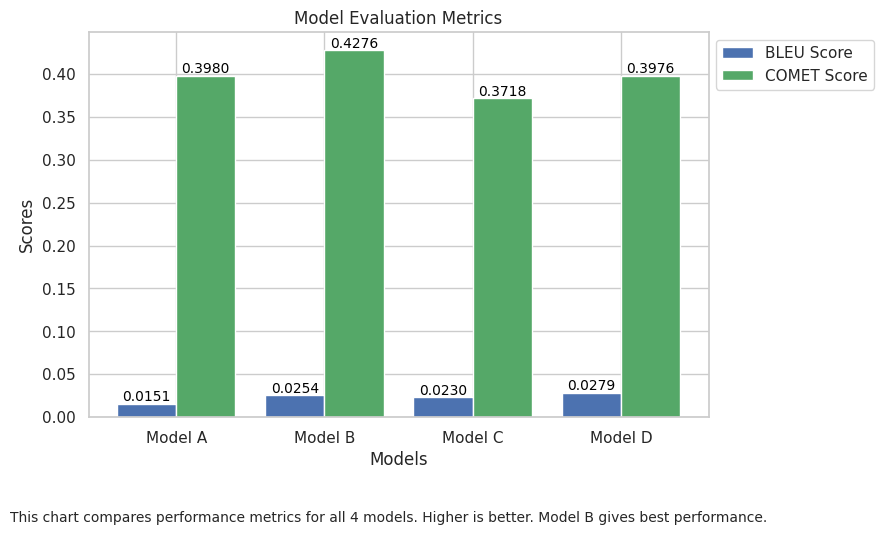

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Extract values
models = [d['model'] for d in evaluation_results]
bleu_scores = [d['bleu score'] for d in evaluation_results]
comet_scores = [d['comet score'] for d in evaluation_results]

# Bar Width
x = np.arange(len(models))  # Model positions
width = 0.4

# Plot Bars
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, bleu_scores, width, label="BLEU Score", color='b')
bars2 = ax.bar(x + width/2, comet_scores, width, label="COMET Score", color='g')

# Add Value Labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}", ha='center', va='bottom', fontsize=10, color='black')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}", ha='center', va='bottom', fontsize=10, color='black')

# Labels & Formatting
ax.set_xlabel("Models")
ax.set_ylabel("Scores")
ax.set_title("Model Evaluation Metrics")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Moves legend outside top-right

plt.figtext(0.5, -0.1, "This chart compares performance metrics for all 4 models. Higher is better. Model B gives best performance.",
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()
